# Import

In [873]:
#общий импорт
import pandas as pd #для работы с таблицами
import numpy as np #для работы с массивами
import matplotlib.pyplot as plt #для работы с графиками
import seaborn as sns #для визуализации статистических взаимосвязей
pd.set_option("display.max_columns", None)

#препроцессинг
from sklearn.preprocessing import LabelEncoder #для кодирования категориальных признаков
from sklearn.preprocessing import StandardScaler, RobustScaler #для стандартизации признаков
from sklearn.model_selection import (train_test_split,  # для разделения данных на тренировочную и тестовую выборки
                                     GridSearchCV) #для подбора гиперпараметров методом сетки
from sklearn.pipeline import make_pipeline

#ML регрессия
from sklearn.linear_model import LinearRegression # линейная регрессия
from sklearn.linear_model import Lasso # Lasso регрессия
from sklearn.linear_model import ElasticNet # линейная регрессия
from sklearn.neighbors import KNeighborsRegressor # метод ближайших соседей
from sklearn.tree import DecisionTreeRegressor # решающее дерево
from sklearn.svm import SVR # метод опорных векторов
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.kernel_ridge import KernelRidge



#метрики оценки качества моделей регрессии
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             r2_score)

import pickle #для сохранения модели

# Загрузка данных

In [874]:
#путь до датасета
path_to_train = 'house_prices/train.csv'
path_to_test  = 'house_prices/test.csv'

In [875]:
train = pd.read_csv(path_to_train, index_col=0)
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Описательный анализ

In [876]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

In [877]:
train.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [878]:
train.describe(include='object')

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,588,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,445,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,3,157,49,1267,1198


In [879]:
#размерность
train.shape

(1460, 80)

In [880]:
train['Fence'].value_counts()

Fence
MnPrv    157
GdPrv     59
GdWo      54
MnWw      11
Name: count, dtype: int64

##Работа с пропусками

<Axes: ylabel='Id'>

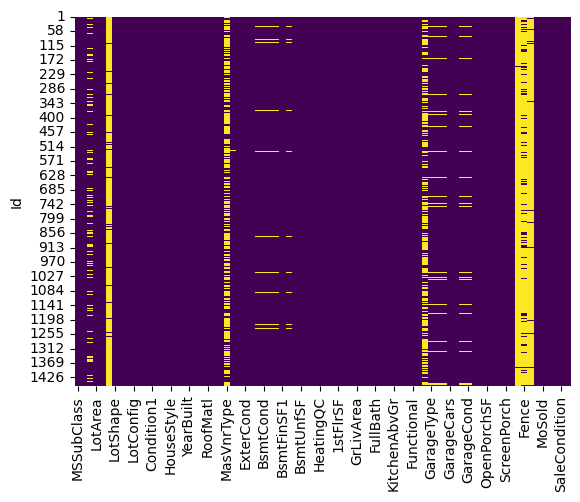

In [881]:
sns.heatmap(train.isna(), cmap = 'viridis', cbar = False)

In [882]:
train.isna().sum()

MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 80, dtype: int64

In [883]:
#считаем пропуски в процентах
train.isna().sum()[train.isna().sum() > 0] / train.shape[0] * 100

LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64

### Примеры заполнения пропусков

In [884]:
train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [885]:
train['LotFrontage'].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

In [886]:
train['LotFrontage'].corr(train['SalePrice'])

np.float64(0.35179909657067804)

In [887]:
#список методов заполнения
methods_list = [0,
                train['LotFrontage'].min(),
                train['LotFrontage'].max(),
                train['LotFrontage'].mean(),
                train['LotFrontage'].median(),
                train['LotFrontage'].quantile(0.3),
                train['LotFrontage'].quantile(0.5),
                train['LotFrontage'].quantile(0.7),
                train['LotFrontage'].quantile(0.9)]
methods_names = ['0',
                 'min',
                 'max',
                 'mean',
                 'median',
                 '0.3 quantile',
                 '0.5 quantile',
                 '0.7 quantile',
                 '0.9 quantile']

In [888]:
for i in range(len(methods_list)):
  print(f'для метода {methods_names[i]}',
        'корреляция с SalePrice =', train['LotFrontage'].fillna(methods_list[i]).corr(train['SalePrice']).round(4))
  # выбираем тот метод заполнения пропусков, который дает максимальную корреляциюс целевой переменной (после заполнения)

для метода 0 корреляция с SalePrice = 0.2096
для метода min корреляция с SalePrice = 0.2524
для метода max корреляция с SalePrice = 0.0813
для метода mean корреляция с SalePrice = 0.3349
для метода median корреляция с SalePrice = 0.3348
для метода 0.3 quantile корреляция с SalePrice = 0.3292
для метода 0.5 quantile корреляция с SalePrice = 0.3348
для метода 0.7 quantile корреляция с SalePrice = 0.3316
для метода 0.9 quantile корреляция с SalePrice = 0.3071


In [889]:
def remove_all_outliers_iqr(data):
    """
    Удаляет выбросы по всем числовым колонкам используя метод IQR
    """
    original_size = len(data)
    
    # Выбираем только числовые колонки
    numeric_columns = data.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"Анализируем {len(numeric_columns)} числовых колонок...")
    
    # Находим индексы выбросов для каждой колонки
    all_outliers_indices = set()
    
    for column in numeric_columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Находим выбросы для текущей колонки
        column_outliers = data[
            (data[column] < lower_bound) | 
            (data[column] > upper_bound)
        ].index
        
        all_outliers_indices.update(column_outliers)
        
        print(f"{column}: {len(column_outliers)} выбросов")
    
    # Удаляем все строки, содержащие выбросы в любой колонке
    data_clean = data[~data.index.isin(all_outliers_indices)].copy()
    
    print(f"\nРезультат:")
    print(f"Исходный размер: {original_size}")
    print(f"Найдено выбросов: {len(all_outliers_indices)}")
    print(f"Очищенный размер: {len(data_clean)}")
    print(f"Удалено строк: {original_size - len(data_clean)}")
    
    return data_clean

# Использование
# train = remove_all_outliers_iqr(train)

## Исследуем зависимости

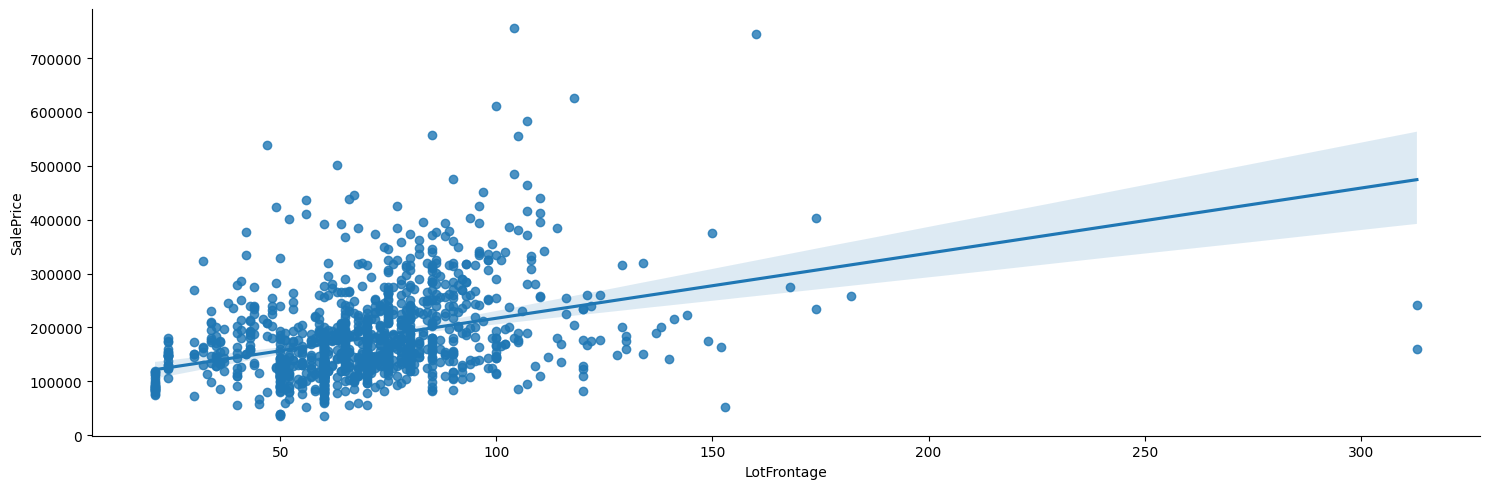

In [890]:
sns.lmplot(data = train, x = 'LotFrontage', y = 'SalePrice', aspect = 3)
plt.show()

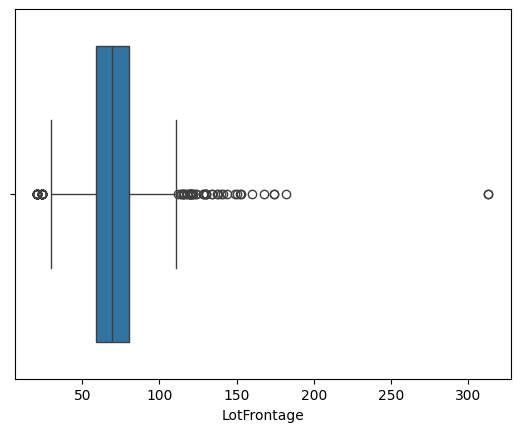

In [891]:
sns.boxplot(train['LotFrontage'], orient = 'h')
plt.show()

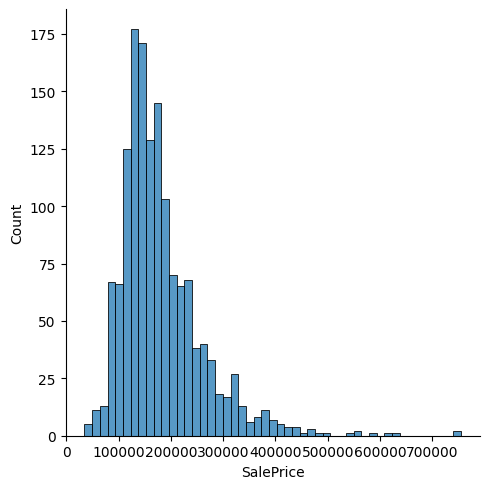

In [892]:
sns.displot(train['SalePrice'])
plt.show()

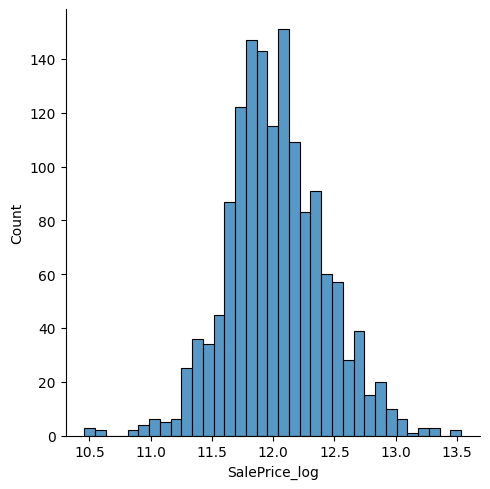

In [893]:
train['SalePrice_log'] = np.log(train['SalePrice'])
sns.displot(train['SalePrice_log'])
plt.show()

In [894]:
train[train['LotFrontage'] >= 130].shape[0]

21

## Обработка категориальных признаков

In [895]:
# Создаем копию исходного датафрейма, чтобы не изменять его
train_encoded = train.copy()

# Выбираем только категориальные столбцы
categorical_cols = train_encoded.select_dtypes(include='object').columns

# Применяем LabelEncoder к каждому категориальному столбцу
for col in categorical_cols:
    le = LabelEncoder()
    train_encoded[col] = le.fit_transform(train_encoded[col])

# Выводим первые 5 строк нового датафрейма с закодированными признаками
display(train_encoded.head())

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,3,65.0,8450,1,2,3,3,0,4,0,5,2,2,0,5,7,5,2003,2003,1,1,12,13,1,196.0,2,4,2,2,3,3,2,706,5,0,150,856,1,0,1,4,856,854,0,1710,1,0,2,1,3,1,2,8,6,0,5,1,2003.0,1,2,548,4,4,2,0,61,0,0,0,0,3,4,4,0,2,2008,8,4,208500,12.247694
2,20,3,80.0,9600,1,2,3,3,0,2,0,24,1,2,0,2,6,8,1976,1976,1,1,8,8,3,0.0,3,4,1,2,3,1,0,978,5,0,284,1262,1,0,1,4,1262,0,0,1262,0,1,2,0,3,1,3,6,6,1,4,1,1976.0,1,2,460,4,4,2,298,0,0,0,0,0,3,4,4,0,5,2007,8,4,181500,12.109011
3,60,3,68.0,11250,1,2,0,3,0,4,0,5,2,2,0,5,7,5,2001,2002,1,1,12,13,1,162.0,2,4,2,2,3,2,2,486,5,0,434,920,1,0,1,4,920,866,0,1786,1,0,2,1,3,1,2,6,6,1,4,1,2001.0,1,2,608,4,4,2,0,42,0,0,0,0,3,4,4,0,9,2008,8,4,223500,12.317167
4,70,3,60.0,9550,1,2,0,3,0,0,0,6,2,2,0,5,7,5,1915,1970,1,1,13,15,3,0.0,3,4,0,3,1,3,0,216,5,0,540,756,1,2,1,4,961,756,0,1717,1,0,1,0,3,1,2,7,6,1,2,5,1998.0,2,3,642,4,4,2,0,35,272,0,0,0,3,4,4,0,2,2006,8,0,140000,11.849398
5,60,3,84.0,14260,1,2,0,3,0,2,0,15,2,2,0,5,8,5,2000,2000,1,1,12,13,1,350.0,2,4,2,2,3,0,2,655,5,0,490,1145,1,0,1,4,1145,1053,0,2198,1,0,2,1,4,1,2,9,6,1,4,1,2000.0,1,3,836,4,4,2,192,84,0,0,0,0,3,4,4,0,12,2008,8,4,250000,12.429216


In [896]:
def encoding(data):
    data_encoded = data
    # Выбираем только категориальные столбцы
    categorical_cols = data_encoded.select_dtypes(include='object').columns
    # Применяем LabelEncoder к каждому категориальному столбцу
    for col in categorical_cols:
        le = LabelEncoder()
        data_encoded[col] = le.fit_transform(data_encoded[col])
    return data_encoded


## Корреляция

<Axes: >

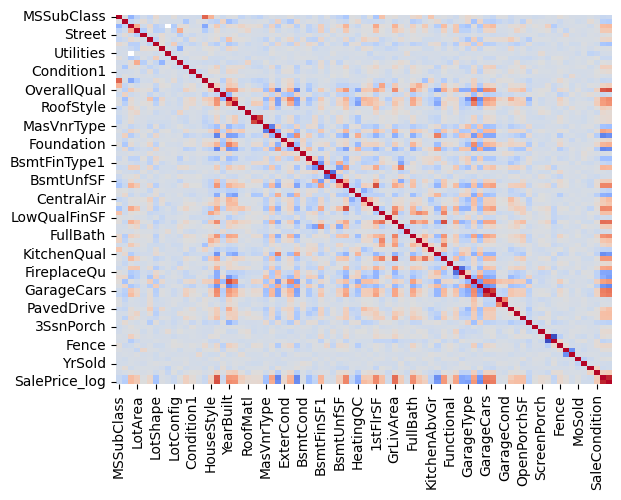

In [897]:
sns.heatmap(train_encoded.corr(), cmap = 'coolwarm',  cbar = False)

In [898]:
#TOP K коррелируемых прихнако
k = 10
corrmat = train_encoded.corr()
top_corr_features = corrmat.nlargest(k, 'SalePrice')[['SalePrice']]
top_corr_features

,SalePrice
SalePrice,1.000000
SalePrice_log,0.948374
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723


In [899]:
cols = top_corr_features.index.to_list() #выдергиваем имена колонок

<Axes: >

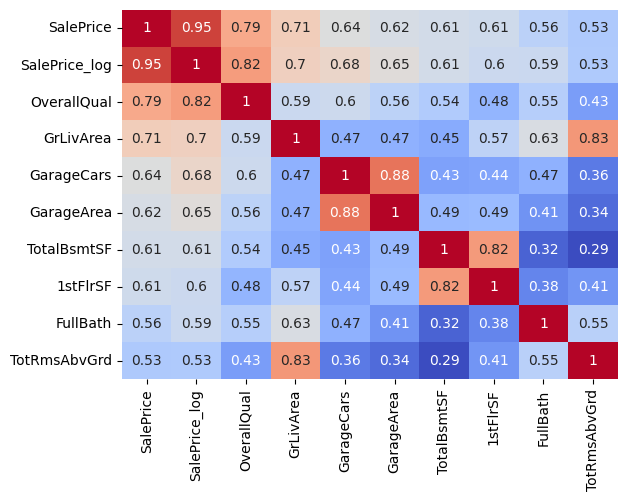

In [900]:
sns.heatmap(train_encoded[cols].corr(), cmap = 'coolwarm',  cbar = False, annot = True)

# Preprocessing

## заполнение пропусков средним

<Axes: ylabel='Id'>

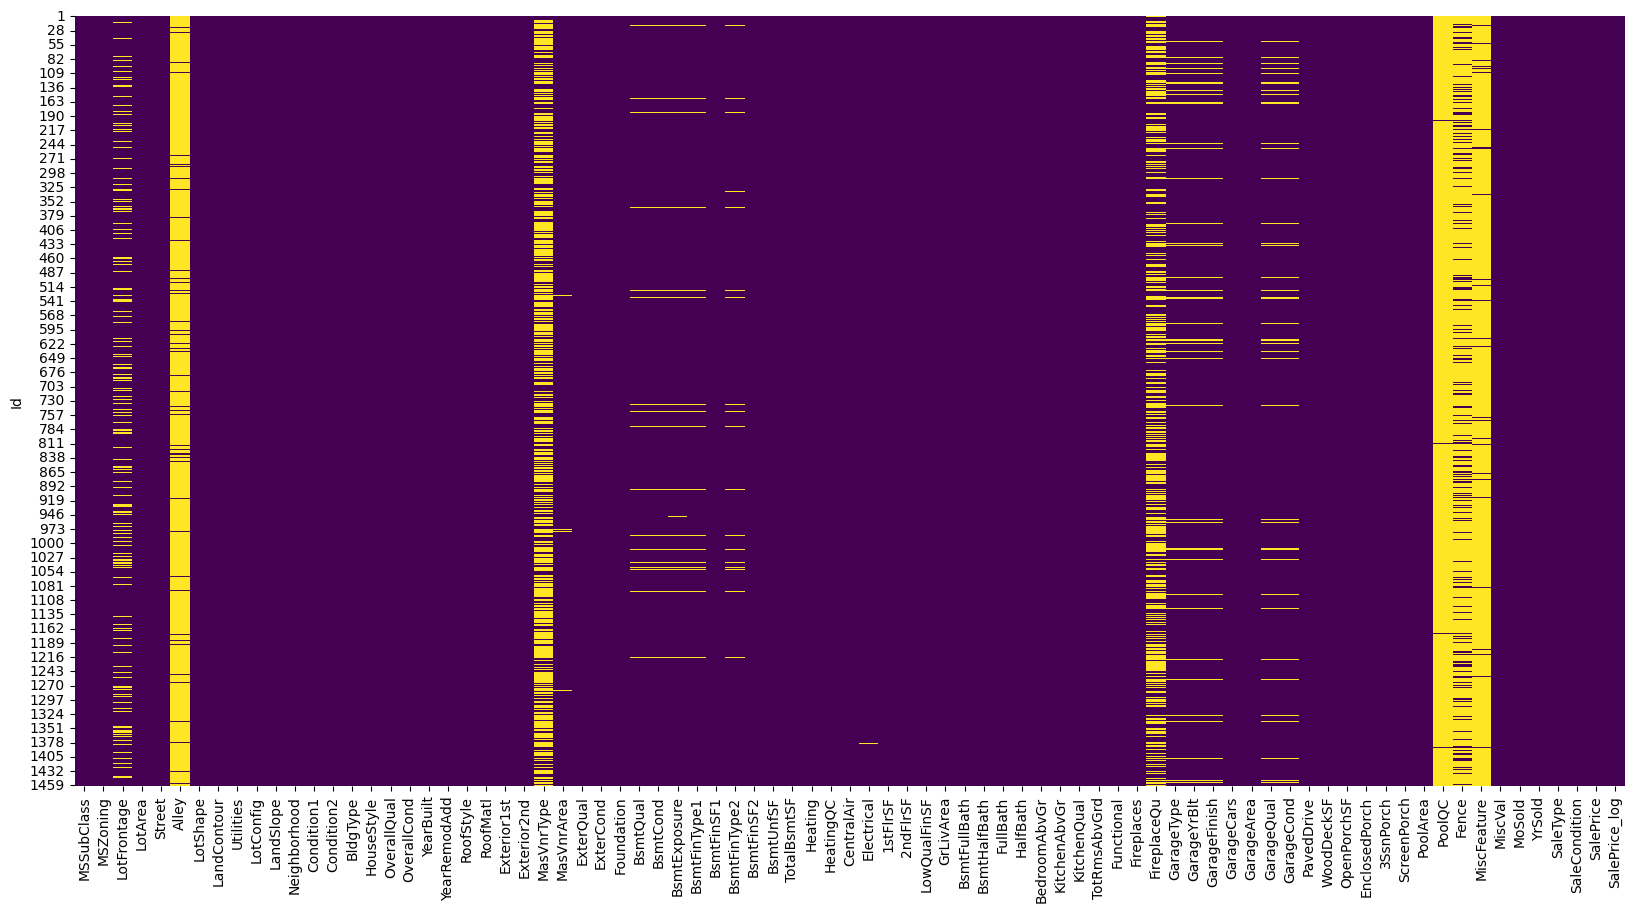

In [901]:
plt.figure(figsize = (20, 10))
sns.heatmap(train.isna(), cmap = 'viridis', cbar = False)

In [902]:
#считаем пропуски в процентах
temp_data = train.isna().sum()[train.isna().sum() > 0] / train.shape[0] * 100

In [903]:
cols_to_drop = (temp_data[temp_data > 30]).index.to_list()

In [904]:
train_encoded.drop(cols_to_drop, axis = 1, inplace = True)

In [905]:
def drop_cols(data):
    temp_data = data.isna().sum()[data.isna().sum() > 0] / data.shape[0] * 100
    cols_to_drop = (temp_data[temp_data > 30]).index.to_list()
    data.drop(cols_to_drop, axis = 1, inplace = True)
    return data

<Axes: ylabel='Id'>

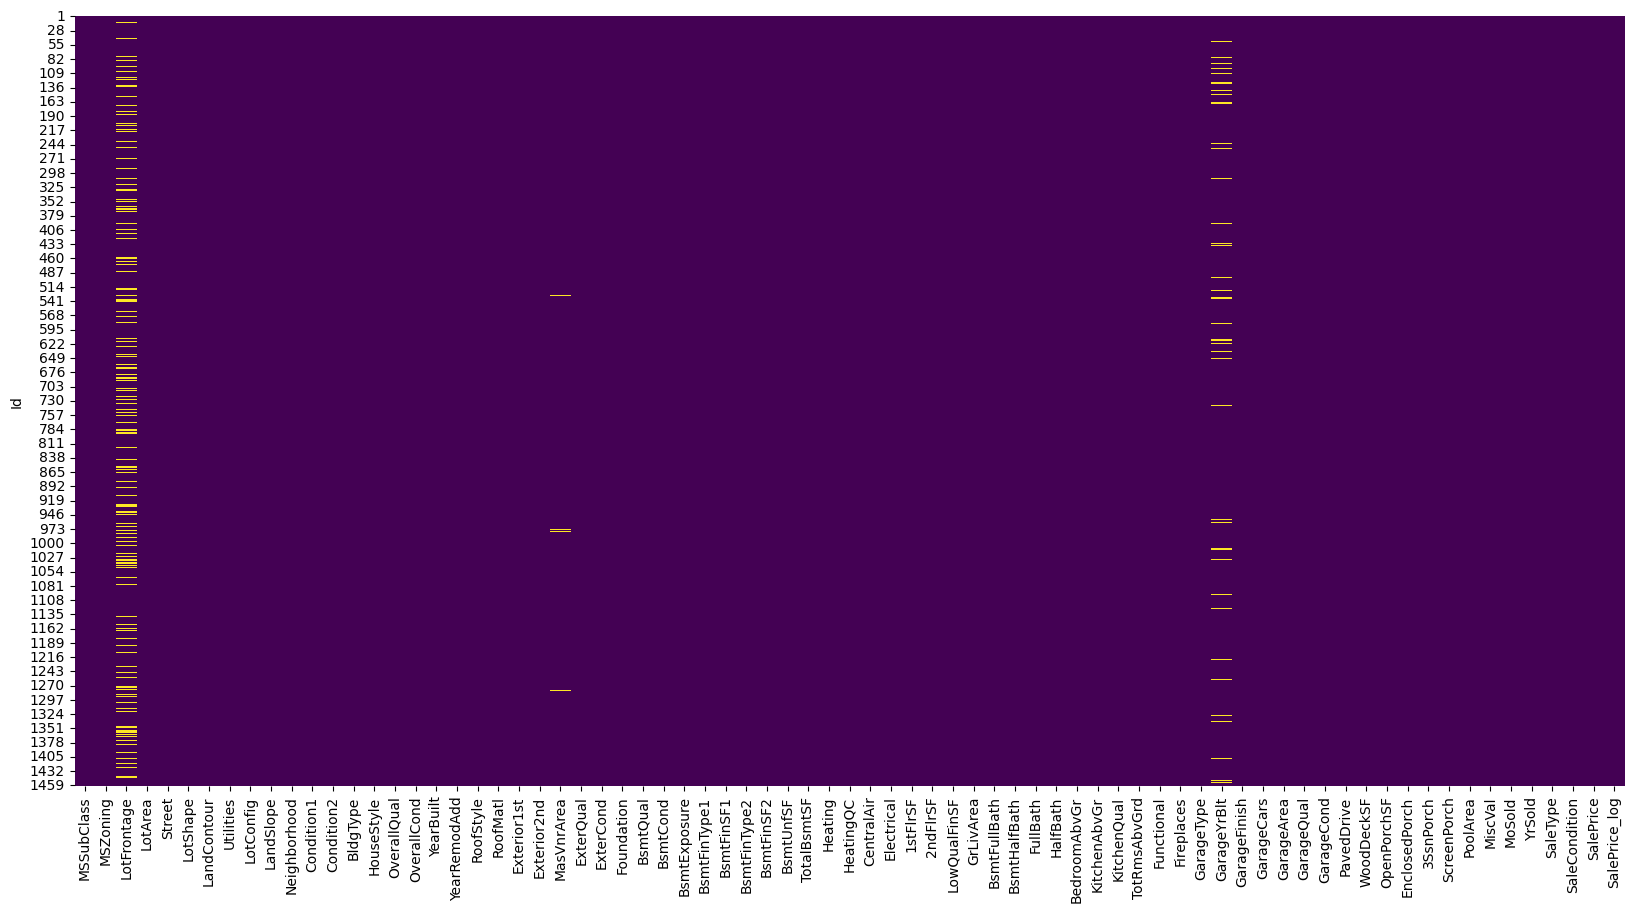

In [906]:
plt.figure(figsize = (20, 10))
sns.heatmap(train_encoded.isna(), cmap = 'viridis', cbar = False)

In [907]:
for i in train_encoded.columns.to_list():
  train_encoded[i].fillna(train_encoded[i].mean(), inplace = True)

/tmp/ipykernel_1401712/2291377535.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_encoded[i].fillna(train_encoded[i].mean(), inplace = True)


In [908]:
def fill_miss(data):
    for column in data.columns.to_list():
        data[column].fillna(data[column].mean(), inplace=True)
    return data

<Axes: ylabel='Id'>

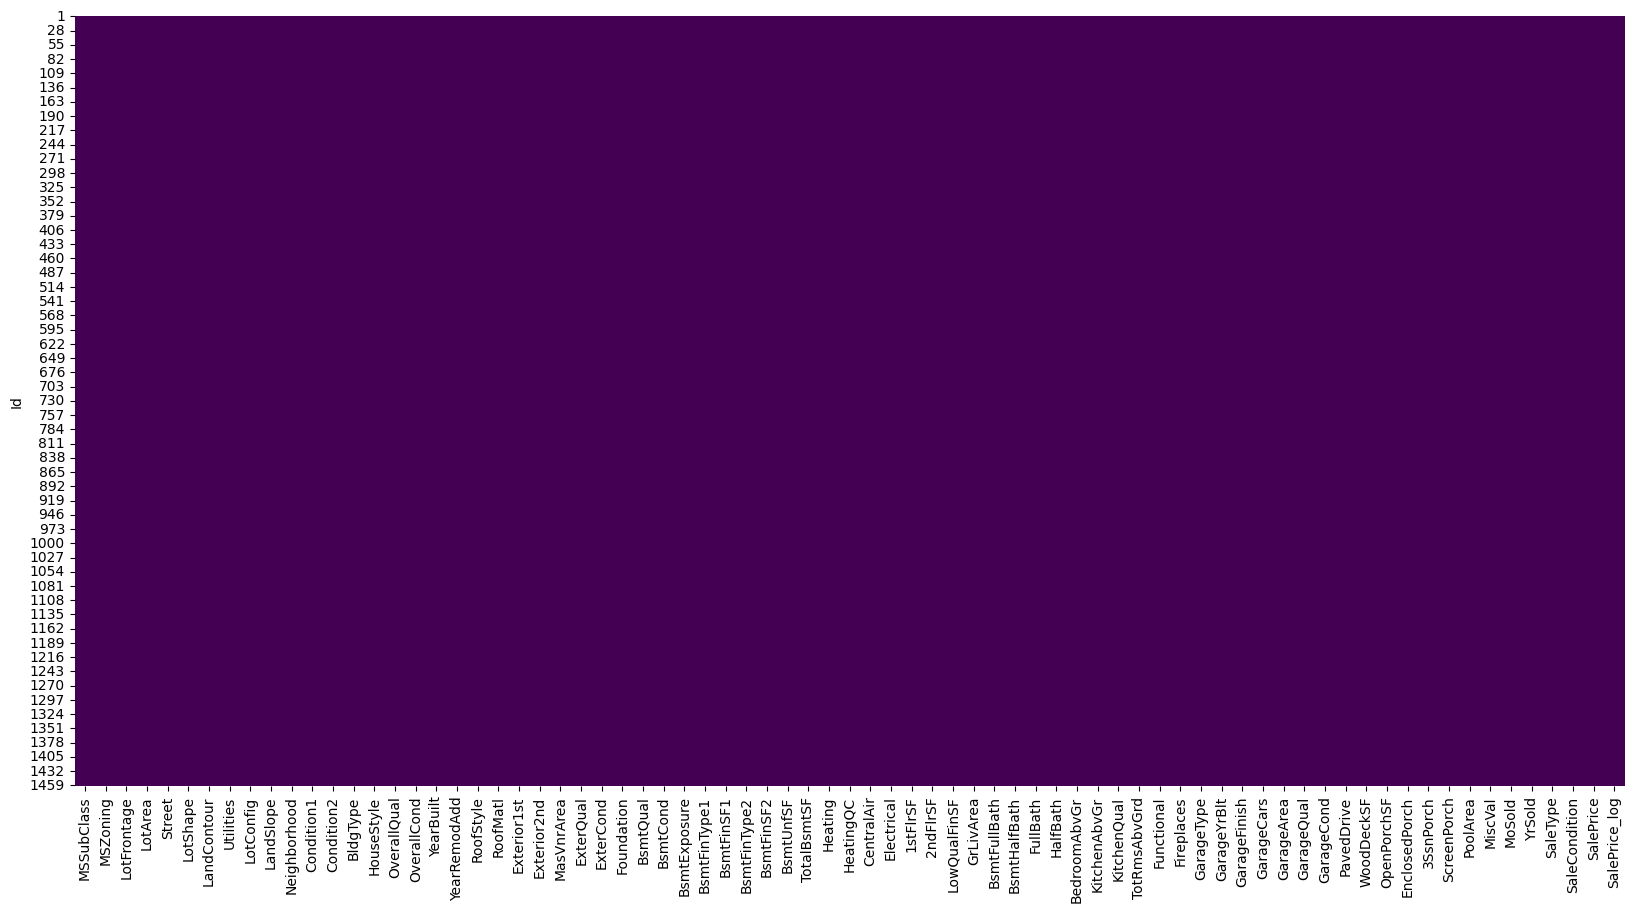

In [909]:
plt.figure(figsize = (20, 10))
sns.heatmap(train_encoded.isna(), cmap = 'viridis', cbar = False)

In [910]:
train["SalePrice_log"].describe()

count    1460.000000
mean       12.024051
std         0.399452
min        10.460242
25%        11.775097
50%        12.001505
75%        12.273731
max        13.534473
Name: SalePrice_log, dtype: float64

## X_train y_train, X_test y_test Готовим выборки

In [911]:
y = (train_encoded['SalePrice_log'])
X = (train_encoded.drop(columns = ['SalePrice', 'SalePrice_log'], axis = 1))

In [912]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    shuffle = True,
                                                    random_state = 42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1168, 73)
(1168,)
(292, 73)
(292,)


## Метрики (get_metrics)




In [913]:
def get_metrics_regression(model_list,
                           model_list_name,
                           X_test, y_test):

  #список с сметриками
  mean_absolute_error_list = []
  mean_squared_error_list = []
  r2_score_list = []

  #цикл по метрикам регрессии
  for i in range(len(model_list)):
    y_pred = model_list[i].predict(X_test)
    print(f'Метрики для модели {model_list_name[i]}')

    print('mae = ', mean_absolute_error(y_test, y_pred))
    print('mse = ', mean_squared_error(y_test, y_pred))
    print('r2', r2_score(y_test, y_pred))

    mean_absolute_error_list.append(round(mean_absolute_error(y_test, y_pred), 3))
    mean_squared_error_list.append(round(mean_squared_error(y_test, y_pred), 3))
    r2_score_list.append(round(r2_score(y_test, y_pred),3))

  #результирующая таблица для сравнения
  result_table = pd.DataFrame(index = model_list_name)
  result_table['mae'] = mean_absolute_error_list
  result_table['mse'] = mean_squared_error_list
  result_table['r2'] = r2_score_list

  return result_table



## Регрессия

In [914]:
def metrics(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    MAE = mean_absolute_error(y_test, y_pred)
    MSE = mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)
    R2 = r2_score(y_test, y_pred)

    print("Метрики регресии")
    print(f"MAE: {MAE}")
    print(f"MSE: {MSE}")
    print(f"R2: {R2}")
    # Визуализация с улучшениями
    plt.figure(figsize=(10, 6))

    # Точечный график предсказаний vs фактические значения
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')

    # Добавляем метрики качества
    # r2 = r2_score(y_test, y_pred)
    # rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    plt.title(f'Regression: Фактические vs Предсказанные значения\nR² = {R2:.3f}, RMSE = {RMSE:.3f}')
    plt.xlabel('Фактические значения')
    plt.ylabel('Предсказанные значения')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



In [915]:
from sklearn.pipeline import make_pipeline

In [916]:
LR = make_pipeline(RobustScaler(), LinearRegression())

Lasso = make_pipeline(RobustScaler(), Lasso(alpha =0.0005, random_state=1))

Enet = make_pipeline(RobustScaler(), ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=1))

KRR = KernelRidge(alpha=0.6, kernel="polynomial", degree=2, coef0=2.5)

XGB = XGBRegressor(colsample_bytree=0.4603, gamma=0.0468, 
                             learning_rate=0.05, max_depth=3, 
                             min_child_weight=1.7817, n_estimators=2200,
                             reg_alpha=0.4640, reg_lambda=0.8571,
                             subsample=0.5213, silent=1,
                              nthread = -1, verbosity=0)



LGB = LGBMRegressor(objective='regression',num_leaves=5,
                              learning_rate=0.05, n_estimators=720,
                              max_bin = 55, bagging_fraction = 0.8,
                              bagging_freq = 5, feature_fraction = 0.2319,
                              feature_fraction_seed=9, bagging_seed=9,
                              min_data_in_leaf =6, min_sum_hessian_in_leaf = 11, verbose=-1)


Метрики регресии
MAE: 0.10622710972466103
MSE: 0.02381935859768676
R2: 0.8723599510832574


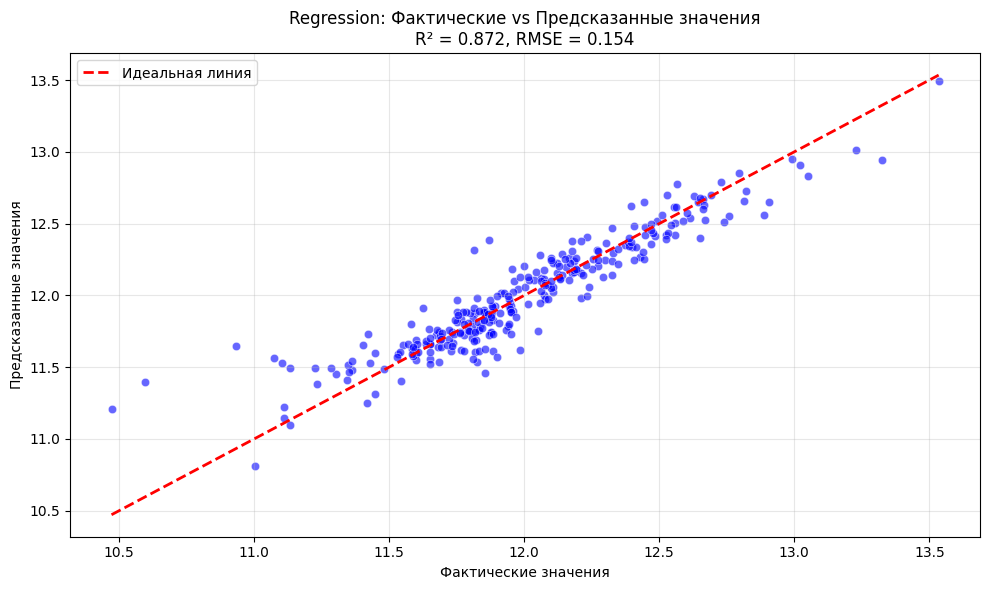

In [917]:
metrics(LR, X_train, y_train, X_test, y_test)


Метрики регресии
MAE: 0.10516381649907716
MSE: 0.023663948674203423
R2: 0.8731927413598808


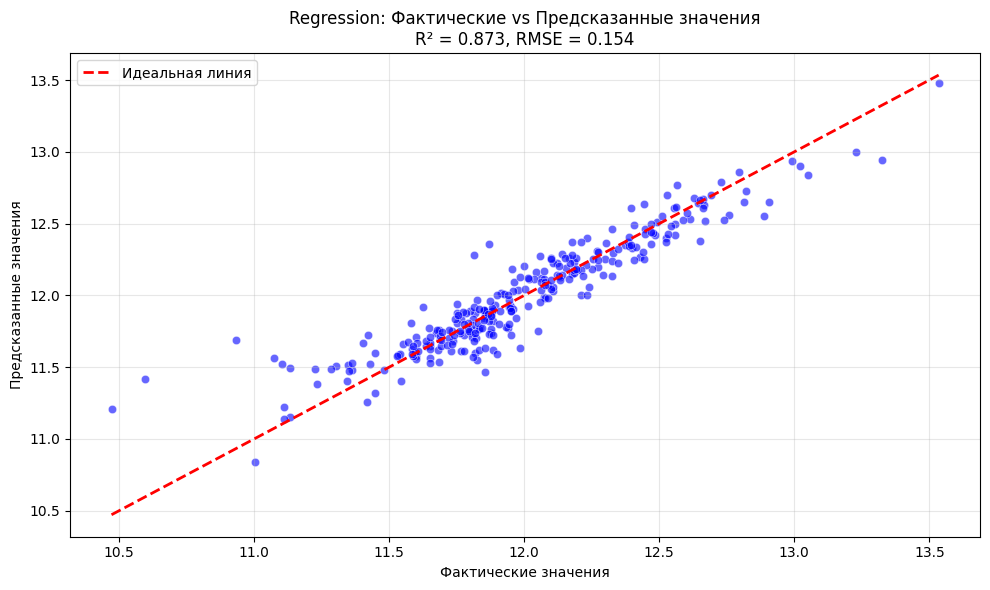

In [918]:
metrics(Lasso, X_train, y_train, X_test, y_test)


Метрики регресии
MAE: 0.10525568871365991
MSE: 0.023701816359294723
R2: 0.872989820984943


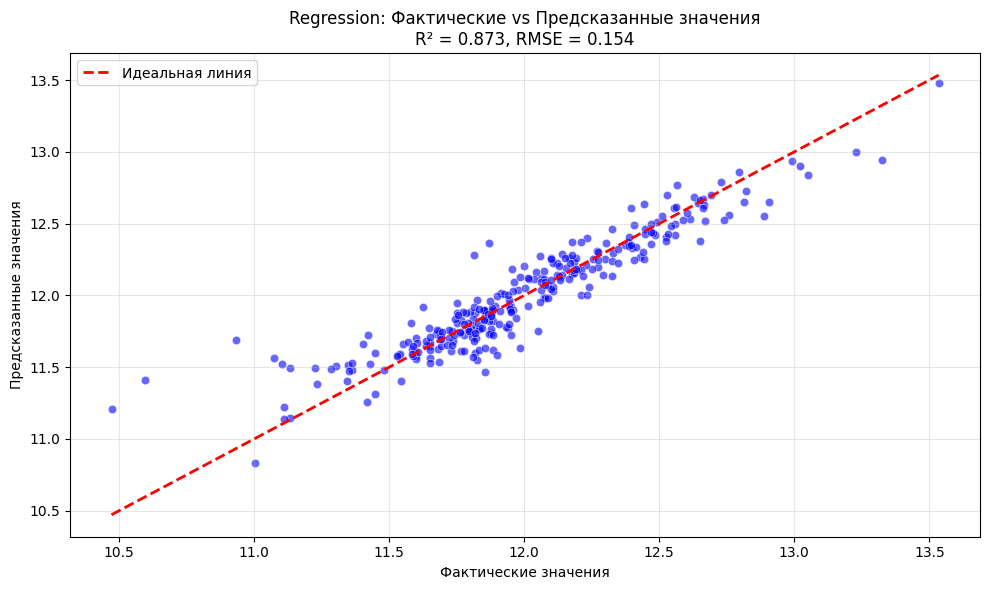

In [919]:
metrics(Enet, X_train, y_train, X_test, y_test)


/home/a210/miniconda3/envs/ml_app/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.37707e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Метрики регресии
MAE: 0.42305775233503473
MSE: 1.0311494336289408
R2: -4.5255880887427224


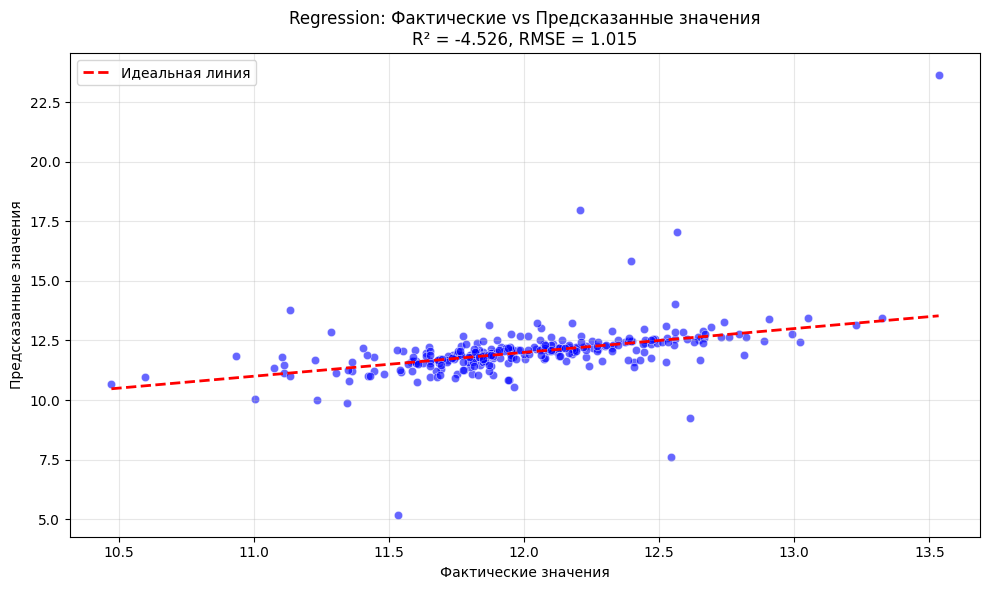

In [920]:
metrics(KRR, X_train, y_train, X_test, y_test)


Метрики регресии
MAE: 0.08543802646115385
MSE: 0.016688026786370148
R2: 0.9105743949149386


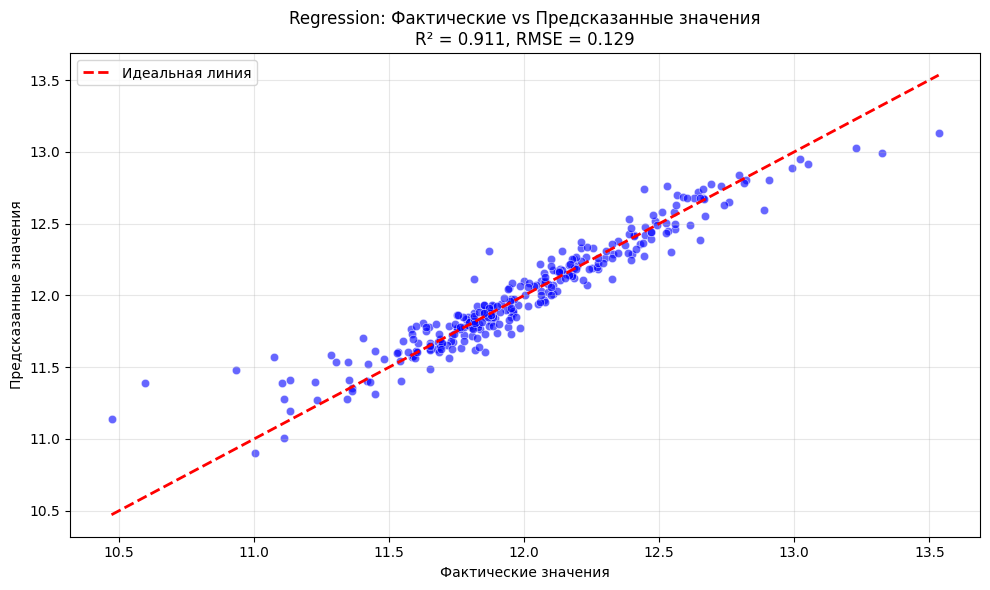

In [921]:
metrics(XGB, X_train, y_train, X_test, y_test)


In [922]:
XGB

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.4603
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [923]:
test = pd.read_csv(path_to_test, index_col='Id')

In [924]:
test

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml


In [925]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1459 entries, 1461 to 2919
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1455 non-null   object 
 2   LotFrontage    1232 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   object 
 5   Alley          107 non-null    object 
 6   LotShape       1459 non-null   object 
 7   LandContour    1459 non-null   object 
 8   Utilities      1457 non-null   object 
 9   LotConfig      1459 non-null   object 
 10  LandSlope      1459 non-null   object 
 11  Neighborhood   1459 non-null   object 
 12  Condition1     1459 non-null   object 
 13  Condition2     1459 non-null   object 
 14  BldgType       1459 non-null   object 
 15  HouseStyle     1459 non-null   object 
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearBuilt 

In [926]:
test.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,1458.000000,1458.000000,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1457.000000,1457.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.00000,1381.000000,1458.000000,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,52.619342,554.294925,1046.117970,1156.534613,325.967786,3.543523,1486.045922,0.434454,0.065202,1.570939,0.377656,2.854010,1.042495,6.385195,0.58122,1977.721217,1.766118,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,176.753926,437.260486,442.898624,398.165820,420.610226,44.043251,485.566099,0.530648,0.252468,0.555190,0.503017,0.829788,0.208472,1.508895,0.64742,26.431175,0.775945,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000,0.000000,407.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.00000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,0.000000,219.250000,784.000000,873.500000,0.000000,0.000000,1117.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.00000,1959.000000,1.000000,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,0.000000,460.000000,988.000000,1079.000000,0.000000,0.000000,1432.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,0.00000,1979.000000,2.000000,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,0.000000,797.750000,1305.000000,1382.500000,676.000000,0.000000,1721.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.00000,2002.000000,2.000000,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,1526.000000,2140.000000,5095.000000,5095.000000,1862.000000,1064.000000,5095.000000,3.000000,2.000000,4.000000,2.000000,6.000000,2.000000,15.000000,4.00000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [927]:
test_encoded = encoding(test)

<Axes: ylabel='Id'>

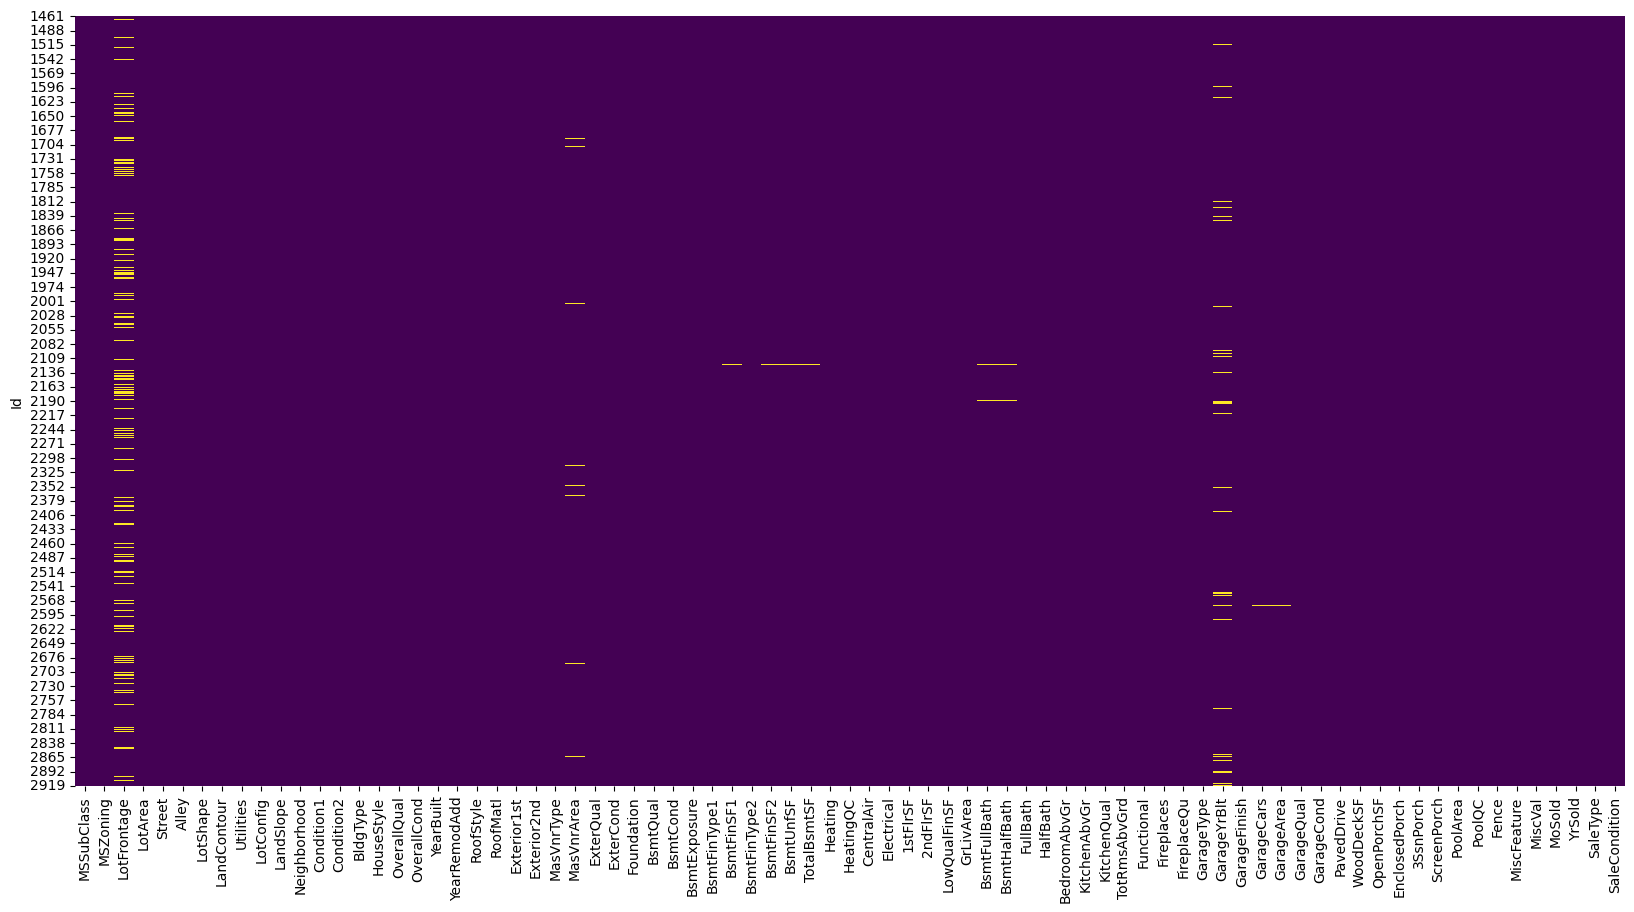

In [928]:
plt.figure(figsize = (20, 10))
sns.heatmap(test_encoded.isna(), cmap = 'viridis', cbar = False)

In [929]:
def preprocessing(data):
    data = encoding(data)
    data = drop_cols(data)
    data = fill_miss(data)
    
    return data



In [930]:
test_preprocessed = preprocessing(test)

/tmp/ipykernel_1401712/1936245653.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna(data[column].mean(), inplace=True)


<Axes: ylabel='Id'>

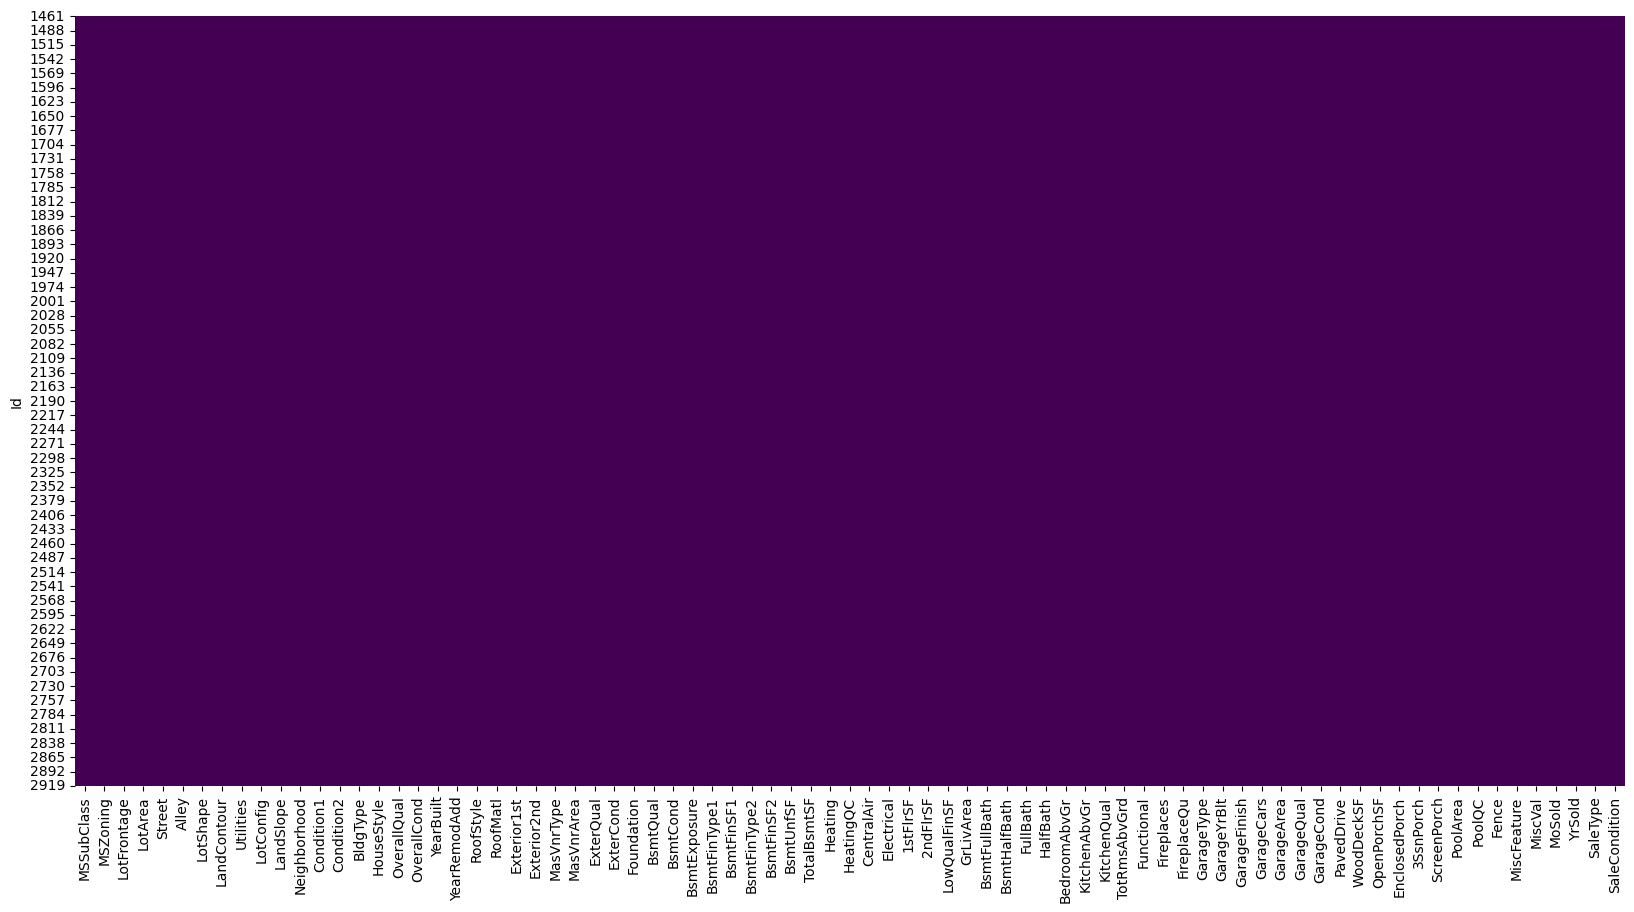

In [931]:
plt.figure(figsize = (20, 10))
sns.heatmap(test_preprocessed.isna(), cmap = 'viridis', cbar = False)

In [932]:
test_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1459 entries, 1461 to 2919
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1459 non-null   int64  
 2   LotFrontage    1459 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   int64  
 5   Alley          1459 non-null   int64  
 6   LotShape       1459 non-null   int64  
 7   LandContour    1459 non-null   int64  
 8   Utilities      1459 non-null   int64  
 9   LotConfig      1459 non-null   int64  
 10  LandSlope      1459 non-null   int64  
 11  Neighborhood   1459 non-null   int64  
 12  Condition1     1459 non-null   int64  
 13  Condition2     1459 non-null   int64  
 14  BldgType       1459 non-null   int64  
 15  HouseStyle     1459 non-null   int64  
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearBuilt 

In [933]:
test_preprocessed.shape


(1459, 79)

In [934]:
XTest = test_preprocessed

In [935]:
train_columns = XGB.get_booster().feature_names
train_columns

['MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch'

In [936]:
# Получаем колонки, которые были при обучении
train_columns = XGB.get_booster().feature_names

print(f"Ожидаемые колонки: {len(train_columns)}")
print(f"Колонки в test: {len(test.columns)}")

# Приводим test к тому же формату
missing_cols = set(train_columns) - set(test.columns)
extra_cols = set(test.columns) - set(train_columns)

print(f"Отсутствующие колонки: {missing_cols}")
print(f"Лишние колонки: {extra_cols}")



Ожидаемые колонки: 73
Колонки в test: 79
Отсутствующие колонки: set()
Лишние колонки: {'PoolQC', 'Fence', 'MasVnrType', 'MiscFeature', 'Alley', 'FireplaceQu'}


In [937]:
# Лишние колонки, которые нужно удалить
extra_columns = ['PoolQC', 'Fence', 'MasVnrType', 'MiscFeature', 'Alley', 'FireplaceQu']

# Удаляем лишние колонки из test
test_aligned = test.drop(columns=extra_columns, errors='ignore')

print(f"Ожидаемые колонки: {len(train_columns)}")
print(f"Колонки в test после удаления: {len(test_aligned.columns)}")

# Убедимся, что порядок колонок совпадает
test_aligned = test_aligned[train_columns]



Ожидаемые колонки: 73
Колонки в test после удаления: 73


In [938]:
predictions = XGB.predict(test_aligned)
predictions

array([11.732831 , 11.959076 , 12.0977125, ..., 11.96913  , 11.681975 ,
       12.287753 ], shape=(1459,), dtype=float32)

In [939]:
predictions_original = np.exp(predictions)
predictions_original

array([124595.9 , 156228.66, 179460.88, ..., 157807.23, 118417.92,
       217021.78], shape=(1459,), dtype=float32)

In [940]:
test_aligned

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1461,20,2,80.0,11622,1,3,3,0,4,0,12,1,2,0,2,5,6,1961,1961,1,0,10,12,0.0,3,4,1,3,3,3,4,468.0,3,144.0,270.0,882.0,0,4,1,3,896,0,0,896,0.0,0.0,1,0,2,1,3,5,6,0,1,1961.000000,2,1.0,730.0,3,4,2,140,0,0,0,120,0,0,6,2010,8,4
1462,20,3,81.0,14267,1,0,3,0,0,0,12,2,2,0,2,6,6,1958,1958,3,0,11,13,108.0,3,4,1,3,3,3,0,923.0,5,0.0,406.0,1329.0,0,4,1,3,1329,0,0,1329,0.0,0.0,1,1,3,1,2,6,6,0,1,1958.000000,2,1.0,312.0,3,4,2,393,36,0,0,0,0,12500,6,2010,8,4
1463,60,3,74.0,13830,1,0,3,0,4,0,8,2,2,0,4,5,5,1997,1998,1,0,10,12,0.0,3,4,2,2,3,3,2,791.0,5,0.0,137.0,928.0,0,2,1,3,928,701,0,1629,0.0,0.0,2,1,3,1,3,6,6,1,1,1997.000000,0,2.0,482.0,3,4,2,212,34,0,0,0,0,0,3,2010,8,4
1464,60,3,78.0,9978,1,0,3,0,4,0,8,2,2,0,4,6,6,1998,1998,1,0,10,12,20.0,3,4,2,3,3,3,2,602.0,5,0.0,324.0,926.0,0,0,1,3,926,678,0,1604,0.0,0.0,2,1,3,1,2,7,6,1,1,1998.000000,0,2.0,470.0,3,4,2,360,36,0,0,0,0,0,6,2010,8,4
1465,120,3,43.0,5005,1,0,1,0,4,0,22,2,2,4,2,8,5,1992,1992,1,0,6,6,0.0,2,4,2,2,3,3,0,263.0,5,0.0,1017.0,1280.0,0,0,1,3,1280,0,0,1280,0.0,0.0,2,0,2,1,2,5,6,0,1,1992.000000,1,2.0,506.0,3,4,2,0,82,0,0,144,0,0,1,2010,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,160,4,21.0,1936,1,3,3,0,4,0,10,2,2,3,4,4,7,1970,1970,1,0,5,5,0.0,3,4,1,3,3,3,5,0.0,5,0.0,546.0,546.0,0,2,1,3,546,546,0,1092,0.0,0.0,1,1,3,1,3,5,6,0,6,1977.721217,3,0.0,0.0,4,5,2,0,0,0,0,0,0,0,6,2006,8,4
2916,160,4,21.0,1894,1,3,3,0,4,0,10,2,2,4,4,4,5,1970,1970,1,0,5,5,0.0,3,4,1,3,3,3,4,252.0,5,0.0,294.0,546.0,0,4,1,3,546,546,0,1092,0.0,0.0,1,1,3,1,3,6,6,0,4,1970.000000,2,1.0,286.0,3,4,2,0,24,0,0,0,0,0,4,2006,8,0
2917,20,3,160.0,20000,1,3,3,0,4,0,11,2,2,0,2,5,7,1960,1996,1,0,10,12,0.0,3,4,1,3,3,3,0,1224.0,5,0.0,0.0,1224.0,0,0,1,3,1224,0,0,1224,1.0,0.0,1,0,4,1,3,7,6,1,5,1960.000000,2,2.0,576.0,3,4,2,474,0,0,0,0,0,0,9,2006,8,0


In [941]:
submission = pd.DataFrame({
    "Id":test_aligned.index,
    "SalePrice": predictions_original
})

In [942]:
submission

,Id,SalePrice
0,1461,124595.898438
1,1462,156228.656250
2,1463,179460.875000
3,1464,190095.156250
4,1465,200178.640625
...,...,...
1454,2915,83685.000000
1455,2916,85139.632812
1456,2917,157807.234375
1457,2918,118417.921875


In [943]:
submission.to_csv('submission.csv', index=False)
print("✅ submission.csv успешно создан!")

# Проверяем результат
print("\n📊 Информация о submission файле:")
print(f"Размер: {submission.shape}")
print(f"Колонки: {submission.columns.tolist()}")
print(f"Количество строк: {len(submission)}")
print(f"Диапазон Id: {submission['Id'].min()} - {submission['Id'].max()}")
print(f"Диапазон цен: ${submission['SalePrice'].min():,.0f} - ${submission['SalePrice'].max():,.0f}")

print("\nПервые 5 строк:")
print(submission.head())

print("\nПоследние 5 строк:")
print(submission.tail())

# Дополнительная проверка на пропущенные значения
print(f"\n🔍 Проверка качества:")
print(f"Пропущенные значения в SalePrice: {submission['SalePrice'].isna().sum()}")
print(f"Медианная цена: ${submission['SalePrice'].median():,.0f}")
print(f"Средняя цена: ${submission['SalePrice'].mean():,.0f}")

✅ submission.csv успешно создан!

📊 Информация о submission файле:
Размер: (1459, 2)
Колонки: ['Id', 'SalePrice']
Количество строк: 1459
Диапазон Id: 1461 - 2919
Диапазон цен: $49,686 - $475,335

Первые 5 строк:
     Id      SalePrice
0  1461  124595.898438
1  1462  156228.656250
2  1463  179460.875000
3  1464  190095.156250
4  1465  200178.640625

Последние 5 строк:
        Id      SalePrice
1454  2915   83685.000000
1455  2916   85139.632812
1456  2917  157807.234375
1457  2918  118417.921875
1458  2919  217021.781250

🔍 Проверка качества:
Пропущенные значения в SalePrice: 0
Медианная цена: $155,383
Средняя цена: $176,299
